In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import timm
from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
try:
    from torchinfo import summary
except ImportError:
    summary = None
from pathlib import Path
from PIL import Image


In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
def first_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return Path(candidates[0])

DATASET_DIR = first_existing_path(
    '/kaggle/input/datasets/thanhhngbch/ds107-imagedetector/cleaned',
    '01-data/cleaned',
    '../01-data/cleaned',
)
SPLIT_DIR = first_existing_path(
    '/kaggle/input/datasets/thanhhngbch/ds107-imagedetector/splits',
    '01-data/splits',
    '../01-data/splits',
)

print(f'DATASET_DIR: {DATASET_DIR}')
print(f'SPLIT_DIR: {SPLIT_DIR}')


'/kaggle/input/datasets/thanhhngbch/ds107-imagedetector/cleaned'

In [5]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
EPOCHS = 50
BATCH_SIZE = 32
NUM_CLASSES = 2
LEARNING_RATE = 1e-4
MODEL_NAME = 'EfficientNetB0'

In [7]:
LABEL_MAP = {'real': 0, 'fake': 1}
CLASS_NAMES = ['real', 'fake']
CLASS_NAMES


['fake', 'real']

In [8]:
class SplitImageDataset(Dataset):
    """Dataset backed by the official train/val/test CSV split files.

    The CSV files were generated with group-aware splitting. Paths inside the CSV
    may be absolute paths from another machine, so the image path is reconstructed
    from DATASET_DIR / label / filename for Kaggle/local portability.
    """

    def __init__(self, csv_path: str | Path, dataset_dir: str | Path = DATASET_DIR, transform=None):
        self.csv_path = Path(csv_path)
        self.dataset_dir = Path(dataset_dir)
        self.transform = transform
        self.df = pd.read_csv(self.csv_path)
        self.label_map = LABEL_MAP

        required_columns = {'path', 'label', 'group_id'}
        missing = required_columns - set(self.df.columns)
        if missing:
            raise ValueError(f'{self.csv_path} is missing columns: {sorted(missing)}')

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        label_name = str(row['label']).lower()
        filename = Path(row['path']).name
        img_path = self.dataset_dir / label_name / filename

        image = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)

        label = self.label_map[label_name]
        return image, torch.tensor(label, dtype=torch.long)


def verify_group_split(split_dir: str | Path = SPLIT_DIR) -> None:
    split_dir = Path(split_dir)
    split_frames = {name: pd.read_csv(split_dir / f'{name}.csv') for name in ['train', 'val', 'test']}
    split_groups = {name: set(df['group_id']) for name, df in split_frames.items()}

    assert len(split_groups['train'] & split_groups['val']) == 0, 'Leakage between train and val'
    assert len(split_groups['train'] & split_groups['test']) == 0, 'Leakage between train and test'
    assert len(split_groups['val'] & split_groups['test']) == 0, 'Leakage between val and test'

    for name, df in split_frames.items():
        print(f"{name}: {len(df)} rows | {df['label'].value_counts().to_dict()}")
    print('No group leakage across train/val/test')


def get_data_loaders(
    dataset_dir: str | Path = DATASET_DIR,
    split_dir: str | Path = SPLIT_DIR,
    batch_size: int = BATCH_SIZE,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders from the official split CSV files.

    Args:
        dataset_dir (str | Path): Path to 01-data/cleaned with real/fake subfolders.
        split_dir (str | Path): Path to train.csv, val.csv and test.csv.
        batch_size (int): Batch size.

    Returns:
        tuple[DataLoader, DataLoader, DataLoader]: train, validation and test loaders.
    """

    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]

    train_transform = v2.Compose([
        v2.Resize(size=256),
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    split_dir = Path(split_dir)
    verify_group_split(split_dir)

    train_set = SplitImageDataset(split_dir / 'train.csv', dataset_dir=dataset_dir, transform=train_transform)
    val_set = SplitImageDataset(split_dir / 'val.csv', dataset_dir=dataset_dir, transform=val_transform)
    test_set = SplitImageDataset(split_dir / 'test.csv', dataset_dir=dataset_dir, transform=val_transform)

    num_workers = 0 if os.name == 'nt' else min(4, os.cpu_count() or 1)
    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

    return train_loader, val_loader, test_loader


In [9]:
def build_efficientnetb0(num_classes: int = NUM_CLASSES) -> nn.Module:
    """Builds a EfficientNetB0 Model.

    Args:
        num_classes (int, optional): Number of output classes for the 
            classification head. Defaults to 2.

    Returns:
        nn.Module: The initialized EfficientNetB0 PyTorch model.
    """
    
    # The timm library automatically downloads the pre-trained ImageNet weights 
    # and safely replaces the final classification head to match `num_classes`.
    model = timm.create_model(
        model_name='efficientnet_b0', 
        pretrained=True, 
        num_classes=num_classes
    )
    
    return model

In [10]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [11]:
def train(train_loader: DataLoader, val_loader: DataLoader, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = LEARNING_RATE, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the EfficientNetB0 using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to LEARNING_RATE.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_efficientnetb0().to(device=device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")

    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 10
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [12]:
def validate(train_loader: DataLoader, val_loader: DataLoader, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline.

    This function performs the following steps:
    1. Trains the model.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train(train_loader=train_loader, val_loader=val_loader)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_efficientnetb0().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [13]:
def test(test_loader: DataLoader, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Evaluate testing pipeline.

    Args:
        test_loader (DataLoader): The DataLoader for the testing dataset.
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the testing set using the best model weights.
    """

    # 1. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_efficientnetb0().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 2. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 3. Inference Loop
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 4. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 5. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 6. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total params: 4,010,110
Trainable params: 4,010,110


Epoch 1/50 | loss: 1.3491 - accuracy: 0.6450 | val_loss: 1.1754 - val_accuracy: 0.6635
val_accuracy improved from 0.0000 to 0.6635, saving weights to /kaggle/working/EfficientNetB0.pth


Epoch 2/50 | loss: 0.6313 - accuracy: 0.7750 | val_loss: 0.9100 - val_accuracy: 0.7055
val_accuracy improved from 0.6635 to 0.7055, saving weights to /kaggle/working/EfficientNetB0.pth


Epoch 3/50 | loss: 0.3928 - accuracy: 0.8437 | val_loss: 0.8187 - val_accuracy: 0.7308
val_accuracy improved from 0.7055 to 0.7308, saving weights to /kaggle/working/EfficientNetB0.pth


...

Epoch 46/50 | loss: 0.0139 - accuracy: 0.9871 | val_loss: 0.4389 - val_accuracy: 0.8702
val_accuracy did not improve from 0.8750


Epoch 47/50 | loss: 0.0182 - accuracy: 0.9846 | val_loss: 0.4516 - val_accuracy: 0.8654
val_accuracy did not improve from 0.8750


Epoch 48/50 | loss: 0.0197 - accuracy: 0.9853 | val_loss: 0.4241 - val_accuracy: 0.8630
val_accuracy did not improve from 0.8750


Epoch 49/50 | loss: 0.0159 - accuracy: 0.9871 | val_loss: 0.4277 - val_accuracy: 0.8690
val_accuracy did not improve from 0.8750


Epoch 50/50 | loss: 0.0189 - accuracy: 0.9856 | val_loss: 0.4388 - val_accuracy: 0.8678
val_accuracy did not improve from 0.8750
early stopping, restoring model weights from the end of the best epoch
            Model      Loss  Accuracy
0  EfficientNetB0  0.440307     0.875
              precision    recall  f1-score   support

        fake       0.88      0.86      0.87       395
        real       0.87      0.89      0.88       437

    accuracy                           0.88       832
   macro avg       0.88      0.87      0.87       832
weighted avg       0.88      0.88      0.87       832



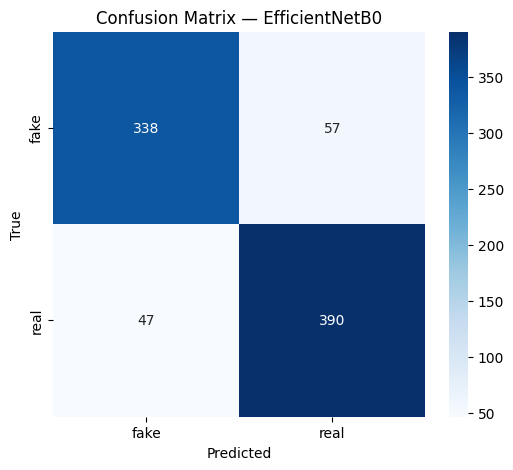

Validation Accuracy: 87.50%
            Model     Loss  Accuracy
0  EfficientNetB0  0.29599  0.887155
              precision    recall  f1-score   support

        fake       0.88      0.88      0.88       387
        real       0.89      0.90      0.89       446

    accuracy                           0.89       833
   macro avg       0.89      0.89      0.89       833
weighted avg       0.89      0.89      0.89       833



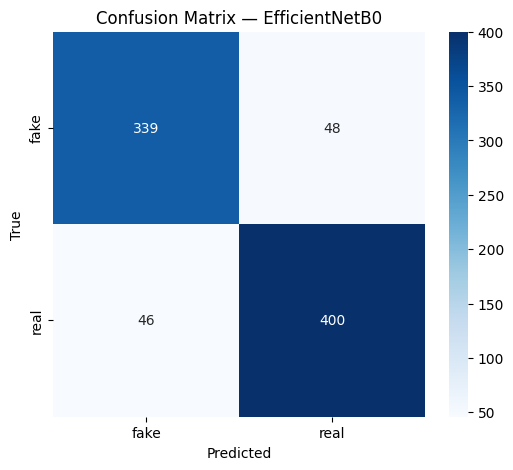

Test Accuracy: 88.72%


In [14]:
train_loader, val_loader, test_loader = get_data_loaders()

acc = validate(train_loader, val_loader)
print(f'Validation Accuracy: {acc * 100:.2f}%')

acc = test(test_loader)
print(f'Test Accuracy: {acc * 100:.2f}%')